# This notebook contains topic trends and visualization for every month  
## Graphs are at the end of the notebook 


#### The results of this study show that NMF is best suited for finding topics in the corpus, while DTM is best suited for finding topic trends over time. Specifically, NMF was found to have the best performance in identifying clear and distinct topics, while DTM was found to be particularly effective in capturing the evolution of topics over time.



## Also checkout Notebooks for:-

### NMF(Non-Negative Matrix Factorization) - https://www.kaggle.com/code/divyapatel4/topic-modelling-and-visualization-using-nmf/
### LDA (Latent Dirichlet Allocation) - https://www.kaggle.com/code/divyapatel4/topic-modelling-and-visualization-using-lda/
### DTM (Dynamic Topic Model) - https://www.kaggle.com/code/divyapatel4/topic-trends-using-dtm-dynamic-topic-models/


## Pre-processing and cleaning of data is done in the following notebook which is used to make cord_df dataset used in this notebook.

### Data Pre-processing and Cleaning - https://www.kaggle.com/code/divyapatel4/cord-19-dataset-cleaner/




# Kindly upvote if you like my work and feel free to comment and suggest changes. It motivates me to do more work. ##

=================================================================================================================


In [ ]:
!pip install gensim==3.8.3

     ━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/24.2 MB 1.1 MB/s eta 0:00:170m

In [1]:
# remove dtm directory if it exists
!rm -rf dtm
!git clone https://github.com/blei-lab/dtm.git

Cloning into 'dtm'...
remote: Enumerating objects: 715, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 715 (delta 21), reused 18 (delta 18), pack-reused 683
Receiving objects: 100% (715/715), 4.48 MiB | 3.30 MiB/s, done.
Resolving deltas: 100% (264/264), done.


In [3]:
!sudo apt-get -y install libgsl0-dev







Note, selecting 'libgsl-dev' instead of 'libgsl0-dev'

The following additional packages will be installed:

  libgsl23 libgslcblas0

Suggested packages:

  gsl-ref-psdoc | gsl-doc-pdf | gsl-doc-info | gsl-ref-html

The following NEW packages will be installed:

  libgsl-dev libgsl23 libgslcblas0

0 upgraded, 3 newly installed, 0 to remove and 74 not upgraded.

Need to get 1998 kB of archives.

After this operation, 9931 kB of additional disk space will be used.

Get:1 http://archive.ubuntu.com/ubuntu focal/universe amd64 libgslcblas0 amd64 2.5+dfsg-6build1 [84.6 kB]

Get:2 http://archive.ubuntu.com/ubuntu focal/universe amd64 libgsl23 amd64 2.5+dfsg-6build1 [850 kB]

Get:3 http://archive.ubuntu.com/ubuntu focal/universe amd64 libgsl-dev amd64 2.5+dfsg-6build1 [1064 kB]

Fetched 1998 kB in 1s (1850 kB/s)

Selecting previously unselected package libgslcblas0:amd64.

(Reading database ... 106350 files and directories currently installed.)

Preparing to unpack .../libgslcblas0_2.5+d

In [4]:
# change to /kaggle/working/dtm/dtm directory using os.chdir
import os
os.chdir('/kaggle/working/dtm/dtm')
!pwd

/kaggle/working/dtm/dtm


In [ ]:
!make

In [6]:
! pip install langdetect
import numpy as np
import pandas as pd 
import glob
import json
import seaborn as sns
from tqdm import tqdm
from langdetect import detect
from langdetect import DetectorFactory

import matplotlib.pyplot as plt
plt.style.use('ggplot')
import math

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
import re
from nltk.stem.snowball import SnowballStemmer
from nltk.tokenize import TweetTokenizer, RegexpTokenizer
import nltk
nltk.download('omw-1.4')
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer 
lemmatizer = WordNetLemmatizer()


from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from operator import itemgetter
import gensim
from gensim.utils import simple_preprocess
import numpy as np

import pprint 

import pyLDAvis
import pyLDAvis.gensim




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 14.2 MB/s eta 0:00:00

  Preparing metadata (setup.py) ... done




  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993242 sha256=8a6eae32d728b5e2a7f312d3df2dfdb362280a70f9778904638465a429670642

  Stored in directory: /root/.cache/pip/wheels/c5/96/8a/f90c59ed25d75e50a8c10a1b1c2d4c402e4dacfa87f3aff36a

Successfully built langdetect






[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...

[nltk_data]   Package wordnet is already up-to-date!

/opt/conda/lib/python3.7/site-packages/past/types/oldstr.py:36: DeprecationWarning: invalid escape sequence \d

  """

/opt/conda/lib/python3.7/site-packages/past/builtins/misc.py:45: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses

  from imp import reload


## Analysis About Top Words After Pre-processing

In [7]:
df = pd.read_csv('/kaggle/input/cord-df/df_10000_processed.csv')

In [8]:
# Get the top 20 most common words among all the articles
p_text = df['processed_text']

# split single string in format of "['word1', 'word2', 'word3', ...]" to list of string ['word1' , 'word2', 'word3', ...]
p_text = p_text.apply(lambda x: x[1:-1].split(', '))
p_text = p_text.apply(lambda x: [item[1:-1] for item in x])
df['processed_text'] = p_text
p_text = [item for sublist in p_text for item in sublist]


## Number of Unique Words...

In [9]:
# Get the number of unique words after processing
num_unique_words = len(set(p_text))
num_unique_words

324401

In [10]:
# count articles in each month 
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['month'] = df['publish_time'].dt.month
df['year'] = df['publish_time'].dt.year

# keep articles from jan 2020 to may 2022
df = df[df['publish_time'] >= '2020-01-01']
df = df[df['publish_time'] < '2022-06-01']

df.head()

,paper_id,doi,abstract,body_text,authors,title,journal,abstract_summary,language,publish_time,word_count,processed_text,month,year
0,e85d5664090aaac23c1714b3d1de71f0b2b882ff,10.1007/s12070-021-02807-2,COVID 19 infections may be associated with a w...,The 2019 novel coronavirus (2019-nCoV) or Seve...,"Desai, Esha J.. Pandya, Achal. Upadhya, Ila...","Epidemiology, Clinical Features and<br>Manage...",Indian J Otolaryngol Head Neck Surg,COVID 19 infections may be associated with a<...,en,2021-08-15,1447,"[novel, coronavirus, ncov, severe_acute_respir...",8,2021
1,5b9e2da60d736bc3b97a54264dab3672cd306e75,10.1111/cen.14540,Background: We sought to evaluate the associat...,States. 4 Many of the abovementioned risk fact...,"Wang, Zhen. Joshi, Avni. Leopold, Kaitlin. ...",Association of vitamin D deficiency with<br>C...,Clin Endocrinol (Oxf),Background: We sought to evaluate the<br>asso...,en,2021-07-12,1430,"[state, abovementioned, risk_factor, modifiabl...",7,2021
2,d3ee272c48f87c9631b2e53c54da884feae32c4a,10.1007/978-3-030-44252-1_2,NaN,historical analysis of the comics selected for...,"Letizia, Angelo J.",Reading Comics for Citizenship,Graphic Novels as Pedagogy in Social Studies,Not provided.,en,2020-04-28,10915,"[historical, analysis, comic, selected, variou...",4,2020
3,90147c26a2ca89ddc175f7bbd591e4991c3b2b54,10.1055/s-0040-1701997,Objectives: Analyze papers published in 2019 w...,Natural Language Processing (NLP) aims at prov...,"Grouin, Cyril. Grabar, Natalia",A Year of Papers Using Biomedical Texts::<br>...,Yearb Med Inform,Objectives: Analyze papers published in 2019<...,en,2020-08-21,2152,"[natural, language, processing, nlp, aim, prov...",8,2020
4,5d1c8d3742ef329635d396f85a127397a691ae88,10.1007/s13304-020-00811-9,"Introduction Recently, Italy has been heavily ...","On the 11th of March, the World Health Organiz...","Pertile, Davide. Gallo, Gaetano. Barra,<br>...",The impact of COVID-19 pandemic on surgical<b...,Updates Surg,"Introduction Recently, Italy has been heavily...",en,2020-06-16,2696,"[th, march, world_health_organization, declare...",6,2020


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>

Int64Index: 9958 entries, 0 to 9994

Data columns (total 14 columns):

 #   Column            Non-Null Count  Dtype         

---  ------            --------------  -----         

 0   paper_id          9958 non-null   object        

 1   doi               9958 non-null   object        

 2   abstract          7082 non-null   object        

 3   body_text         9958 non-null   object        

 4   authors           9906 non-null   object        

 5   title             9958 non-null   object        

 6   journal           9303 non-null   object        

 7   abstract_summary  9958 non-null   object        

 8   language          9958 non-null   object        

 9   publish_time      9958 non-null   datetime64[ns]

 10  word_count        9958 non-null   int64         

 11  processed_text    9958 non-null   object        

 12  month             9958 non-null   int64         

 13  year              9958 non-null   int64         

dtypes: da

[26, 42, 86, 227, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250, 250]


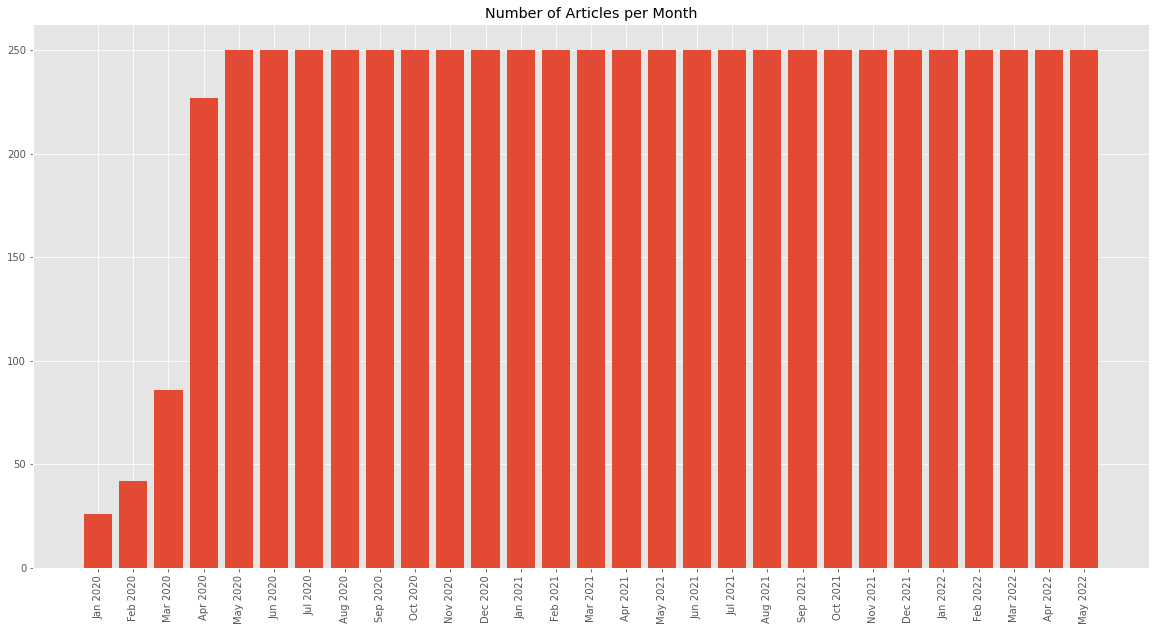

In [12]:

article_per_month =[]
# keep only 300 articles max per month

for year in range (2020, 2023):
    for month in range(1, 13):
        if year == 2022 and month == 6:
            break
        if(len(df[(df['year'] == year) & (df['month'] == month)]) > 250):
            df = df.drop(df[(df['year'] == year) & (df['month'] == month)].sample(n=len(df[(df['year'] == year) & (df['month'] == month)]) - 250).index)
            
        article_per_month.append(len(df[(df['year'] == year) & (df['month'] == month)]))
    
print(article_per_month)


months = ['Jan 2020', 'Feb 2020', 'Mar 2020', 'Apr 2020', 'May 2020', 'Jun 2020', 'Jul 2020', 'Aug 2020', 'Sep 2020', 'Oct 2020', 'Nov 2020', 'Dec 2020', 'Jan 2021', 'Feb 2021', 'Mar 2021', 'Apr 2021', 'May 2021', 'Jun 2021', 'Jul 2021', 'Aug 2021', 'Sep 2021', 'Oct 2021', 'Nov 2021', 'Dec 2021', 'Jan 2022', 'Feb 2022', 'Mar 2022', 'Apr 2022', 'May 2022']

plt.figure(figsize=(20,10))
plt.bar(months, article_per_month)
plt.xticks(rotation=90)
plt.title('Number of Articles per Month')
plt.show()



In [13]:
p_text = df['processed_text']
print(p_text)


0       [novel, coronavirus, ncov, severe_acute_respir...

2       [historical, analysis, comic, selected, variou...

3       [natural, language, processing, nlp, aim, prov...

4       [th, march, world_health_organization, declare...

5       [influenzae, meningitidis, child, died, confir...

                              ...                        

9983    [hypereosinophilia, defined, absolute, eosinop...

9984    [brazil, reported, case, covid, february, date...

9986    [surgical, diathermy, known, electrocautery, u...

9987    [caused, newly, emergent, coronavirus, wa, rec...

9992    [intense, global, concern, economic, developme...

Name: processed_text, Length: 6631, dtype: object


In [14]:
texts = p_text

dictionary = Dictionary(texts)

# Filter out extremes to limit the number of features
dictionary.filter_extremes(
    no_below=0.15,
    no_above=0.7,
    keep_n=int(0.6*num_unique_words)
)

# Create corpus using the dictionary prepared above
corpus = [dictionary.doc2bow(text) for text in texts]


In [15]:
# Apply DTM model
tfidf_vectorizer = TfidfVectorizer(
    min_df=0.15,
    max_df=0.7,
    max_features=int(0.6*num_unique_words),
    stop_words='english'
)
tfidf = tfidf_vectorizer.fit_transform(df['processed_text'].apply(lambda x: ' '.join(x)))

tfidf_fn = tfidf_vectorizer.get_feature_names()


/opt/conda/lib/python3.7/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.

  warnings.warn(msg, category=FutureWarning)


In [16]:
from gensim.models.wrappers import DtmModel


In [17]:
number_of_topics = 10

In [18]:
print(len(corpus))

6631


In [19]:
path_to_dtm_binary = '/kaggle/working/dtm/dtm/main'
dtm_model = DtmModel(path_to_dtm_binary, corpus=corpus,
                     id2word=dictionary, time_slices=article_per_month, 
                     num_topics= number_of_topics , initialize_lda=True, model='fixed')


In [ ]:
# Get the topics for each time slice [month]

print("\n\n\n January 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=0, topn=10)
    pprint.pprint(topics)
    
    
print("\n\n\n February 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=1, topn=10)
    pprint.pprint(topics)
    
print("\n\n\n March 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=2, topn=10)
    pprint.pprint(topics)
    
print("\n\n\n April 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=3, topn=10)
    pprint.pprint(topics)

print("\n\n\n May 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=4, topn=10)
    pprint.pprint(topics)

print("\n\n\n June 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=5, topn=10)
    pprint.pprint(topics)

print("\n\n\n July 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=6, topn=10)
    pprint.pprint(topics)
    
print("\n\n\n August 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=7, topn=10)
    pprint.pprint(topics)
    
print("\n\n\n September 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=8, topn=10)
    pprint.pprint(topics)

print("\n\n\n October 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=9, topn=10)
    pprint.pprint(topics)

print("\n\n\n November 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=10, topn=10)
    pprint.pprint(topics)
    
print("\n\n\n December 2020\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=11, topn=10)
    pprint.pprint(topics)

print("\n\n\n January 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=12, topn=10)
    pprint.pprint(topics)

print("\n\n\n February 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=13, topn=10)
    pprint.pprint(topics)

print("\n\n\n March 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=14, topn=10)
    pprint.pprint(topics)

print("\n\n\n April 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=15, topn=10)
    pprint.pprint(topics)

print("\n\n\n May 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=16, topn=10)
    pprint.pprint(topics)

print("\n\n\n June 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=17, topn=10)
    pprint.pprint(topics)

print("\n\n\n July 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=18, topn=10)
    pprint.pprint(topics)

print("\n\n\n August 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=19, topn=10)
    pprint.pprint(topics)

print("\n\n\n September 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=20, topn=10)
    pprint.pprint(topics)

print("\n\n\n October 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=21, topn=10)
    pprint.pprint(topics)

print("\n\n\n November 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=22, topn=10)
    pprint.pprint(topics)

print("\n\n\n December 2021\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=23, topn=10)
    pprint.pprint(topics)

print("\n\n\n January 2022\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=24, topn=10)
    pprint.pprint(topics)

print("\n\n\n February 2022\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=25, topn=10)
    pprint.pprint(topics)

print("\n\n\n March 2022\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=26, topn=10)
    pprint.pprint(topics)

print("\n\n\n April 2022\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=27, topn=10)
    pprint.pprint(topics)

print("\n\n\n May 2022\n")
for i in range (0,number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=28, topn=10)
    pprint.pprint(topics)

    

## Print above block to get topic words and their residuals, it will be a very long output

# 2020

Topic 0: insulin ali taste venous tomography elevation limb creatinine relapse etiology anatomical disseminated endoscopy edema oxygenation musculoskeletal sensation leg implant acute_respiratory_distress_syndrome_ards

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: se la en ser los cutaneous el longterm del eventual cardiopulmo

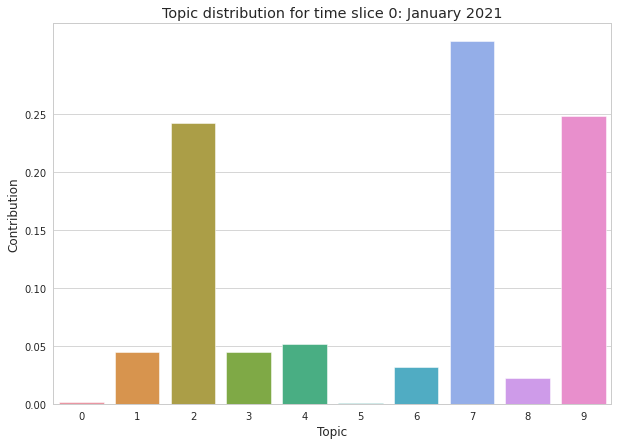

In [21]:
# January 2020


for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=0, topn=20)
    # make a array of words 
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    

topics_contribution_sum = np.zeros(number_of_topics)

for i in range (0,article_per_month[0]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[0]

plt.figure(figsize=(10,7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0,number_of_topics)
# make background white and grid lines light grey   
sns.set_style("whitegrid", {'axes.grid' : True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 0: January 2021")
plt.xticks(range(0,number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_january_2020 = topics_contribution_sum

Topic 0: ali insulin taste venous tomography elevation limb creatinine relapse etiology anatomical disseminated endoscopy edema oxygenation musculoskeletal sensation leg implant acute_respiratory_distress_syndrome_ards

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: se la en ser los cutaneous el longterm del eventual cardiopulmo

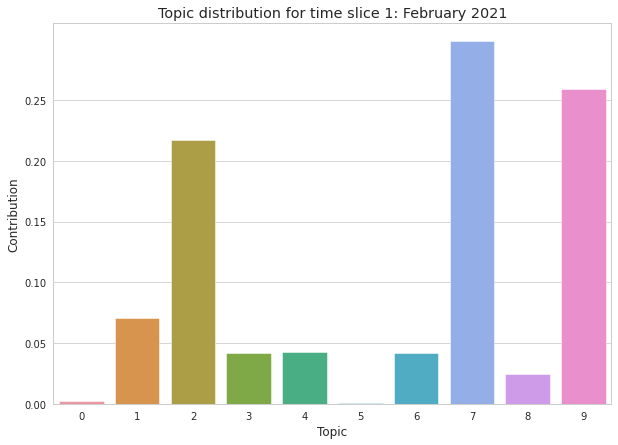

In [22]:
# February 2020
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=1, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0], article_per_month[0] + article_per_month[1]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[1]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
# make background white and grid lines light grey
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 1: February 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()
    
topics_february_2020 = topics_contribution_sum

Topic 0: ali insulin taste venous tomography elevation limb creatinine relapse etiology disseminated anatomical endoscopy oxygenation edema musculoskeletal leg sensation implant acute_respiratory_distress_syndrome_ards

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: se la en ser los el cutaneous longterm del eventual cardiopulmo

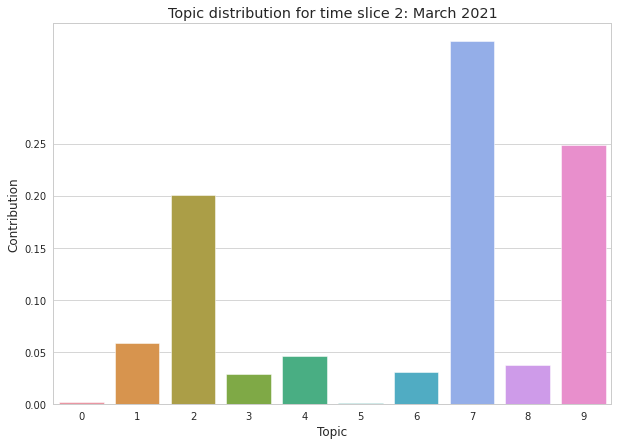

In [23]:
# March
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=2, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1], article_per_month[0] + article_per_month[1] + article_per_month[2]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[2]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 2: March 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_march_2020 = topics_contribution_sum

Topic 0: ali insulin taste venous tomography elevation limb creatinine relapse etiology disseminated endoscopy anatomical oxygenation edema musculoskeletal leg implant sensation acute_respiratory_distress_syndrome_ards

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: se la en ser los el cutaneous longterm del eventual cardiopulmo

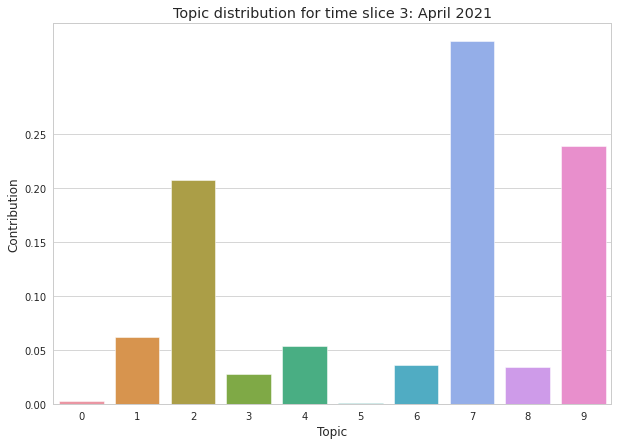

In [24]:
# April
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=3, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[3]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 3: April 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_april_2020 = topics_contribution_sum

Topic 0: ali insulin venous taste tomography elevation limb creatinine relapse etiology endoscopy disseminated oxygenation edema anatomical musculoskeletal implant leg acute_respiratory_distress_syndrome_ards sensation

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi pfizer one-level microdiscectomy

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: se la en ser los el cutaneous longterm del eventual grading car

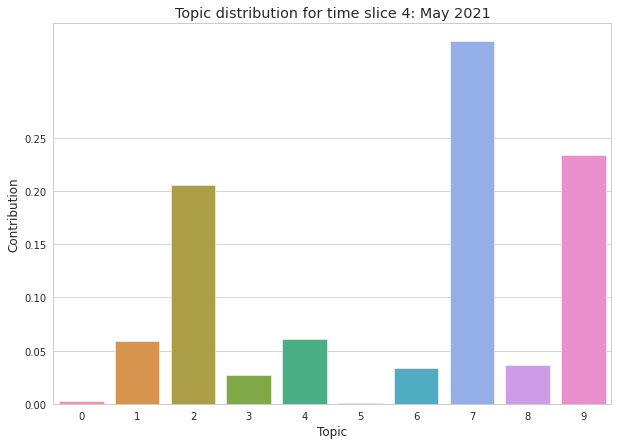

In [25]:
# May
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=4, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[4]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 4: May 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_may_2020 = topics_contribution_sum

Topic 0: ali insulin venous taste tomography elevation limb creatinine relapse endoscopy etiology oxygenation disseminated edema implant anatomical musculoskeletal leg acute_respiratory_distress_syndrome_ards immunoassay

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: se la en ser los el cutaneous longterm del eventual grading c

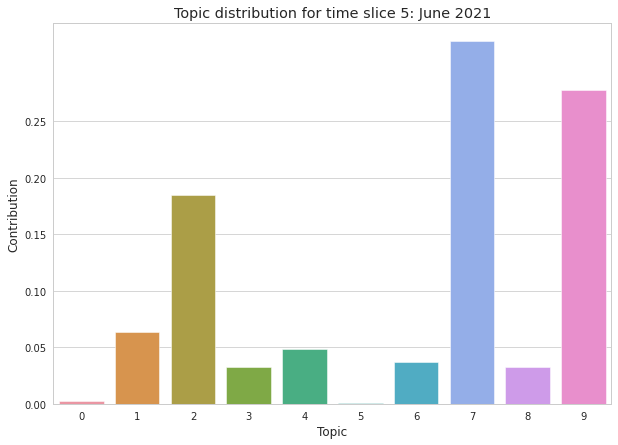

In [26]:
# June
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=5, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[5]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 5: June 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_june_2020 = topics_contribution_sum

Topic 0: ali insulin venous taste tomography elevation limb creatinine relapse endoscopy oxygenation etiology disseminated edema implant anatomical immunoassay musculoskeletal acute_respiratory_distress_syndrome_ards leg

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en ser los el cutaneous del longterm grading eventual c

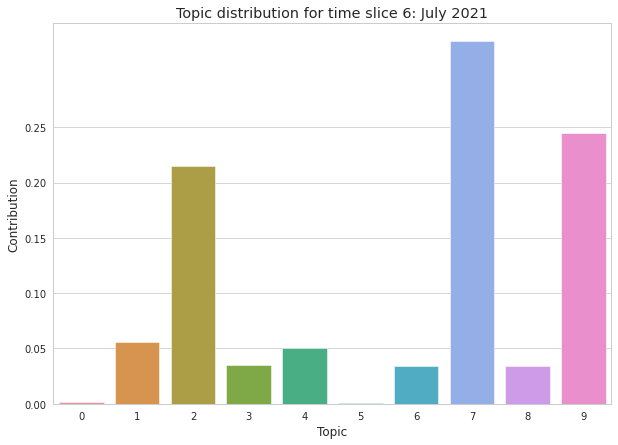

In [27]:
# July
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=6, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[6]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 6: July 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_july_2020 = topics_contribution_sum

Topic 0: ali insulin venous taste tomography elevation limb creatinine relapse oxygenation endoscopy etiology implant edema disseminated immunoassay anatomical acute_respiratory_distress_syndrome_ards pt musculoskeletal

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en ser los el cutaneous del longterm grading eventual ca

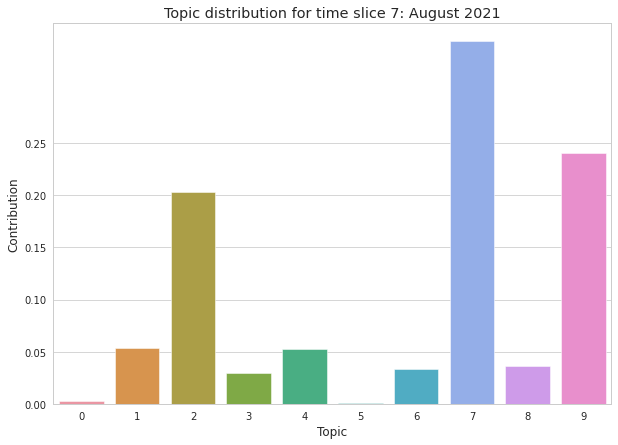

In [28]:
# August
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=7, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[7]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 7: August 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_august_2020 = topics_contribution_sum

Topic 0: ali insulin venous taste elevation tomography limb creatinine oxygenation implant relapse etiology endoscopy edema disseminated immunoassay pt acute_respiratory_distress_syndrome_ards anatomical compensation

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en ser los el cutaneous del grading longterm su cardiopulmo

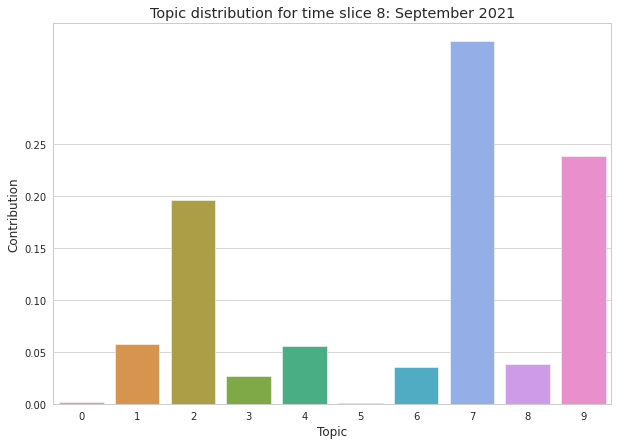

In [29]:
# September
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=8, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[8]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 8: September 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_september_2020 = topics_contribution_sum

Topic 0: ali insulin venous taste limb elevation tomography creatinine implant oxygenation etiology edema relapse endoscopy pt disseminated immunoassay acute_respiratory_distress_syndrome_ards compensation aes

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en ser los el cutaneous grading del longterm su cardiopulmonary ev

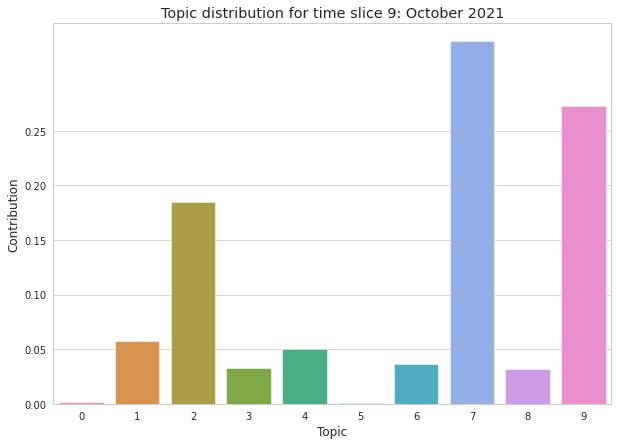

In [30]:
# October
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=9, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[9]
    
plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 9: October 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_october_2020 = topics_contribution_sum

Topic 0: insulin ali venous taste implant limb elevation tomography creatinine oxygenation etiology edema pt compensation relapse endoscopy disseminated immunoassay aes acute_respiratory_distress_syndrome_ards

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en los ser el cutaneous grading del longterm su cardiopulmonar

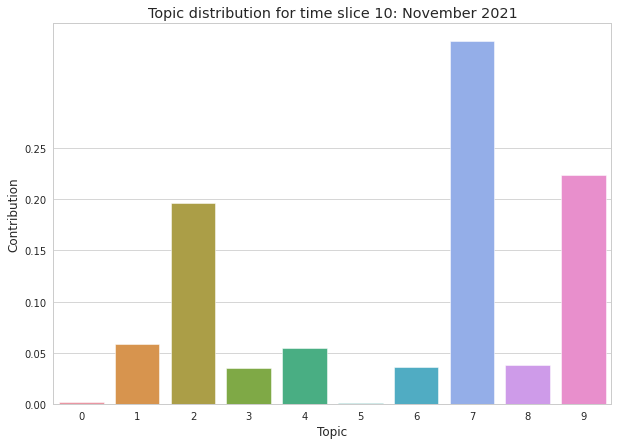

In [31]:
# November
for i in range(0, number_of_topics):

    topics = dtm_model.show_topic(topicid=i, time=10, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[10]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 10: November 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_november_2020 = topics_contribution_sum



Topic 0: insulin implant venous ali taste limb elevation tomography creatinine oxygenation pt etiology edema aes compensation disseminated relapse immunoassay endoscopy acute_respiratory_distress_syndrome_ards

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en los el ser cutaneous grading del longterm su lo cardiopulmo

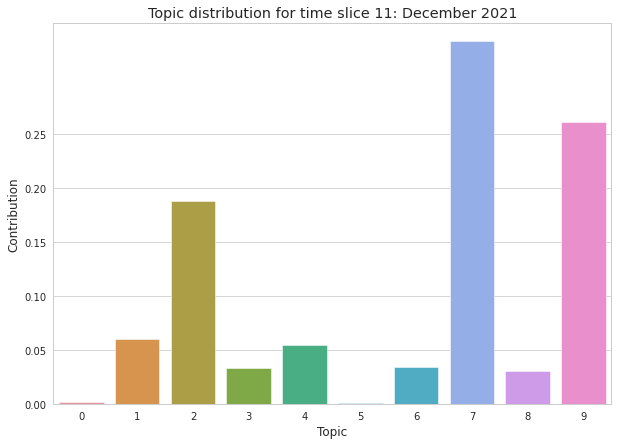

In [32]:
# December
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=11, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)



for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

    
topics_contribution_sum = topics_contribution_sum/article_per_month[11]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 11: December 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_december_2020 = topics_contribution_sum

Topic 0: implant insulin venous taste elevation ali tomography limb creatinine pt aes oxygenation etiology edema compensation disseminated acute_respiratory_distress_syndrome_ards immunoassay relapse endoscopy

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi microdiscectomy one-level ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se los en el ser grading cutaneous su del longterm lo eventual ca

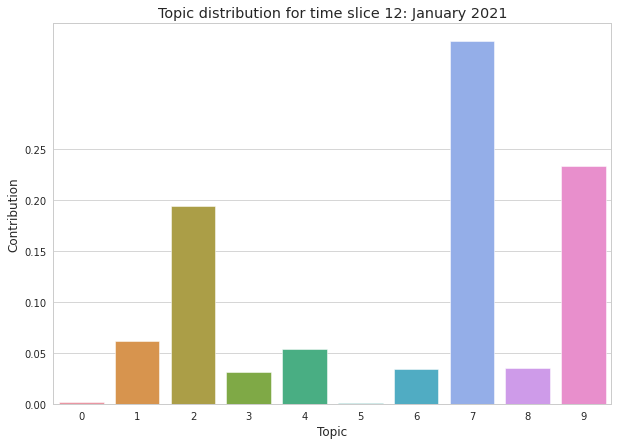

In [33]:
# January 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=12, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics
    
topics_contribution_sum = topics_contribution_sum/article_per_month[12]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 12: January 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_january_2021 = topics_contribution_sum

Topic 0: implant insulin venous taste tomography elevation limb pt ali aes creatinine etiology edema oxygenation compensation disseminated leg acute_respiratory_distress_syndrome_ards immunoassay relapse

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se los en el grading ser cutaneous su del longterm lo eventual para car

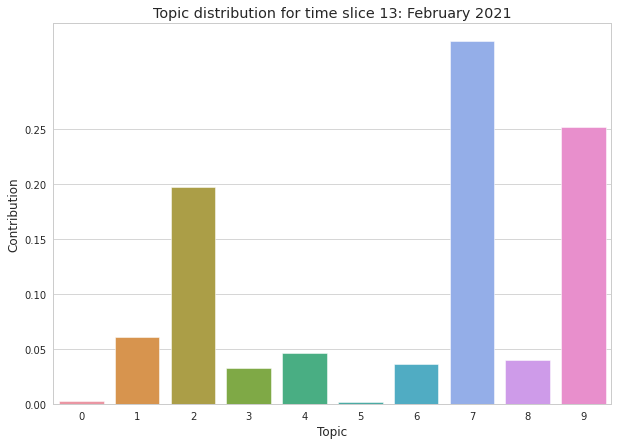

In [34]:
# February 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=13, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[13]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 13: February 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_february_2021 = topics_contribution_sum

Topic 0: implant insulin taste venous tomography elevation limb pt aes creatinine etiology edema ali oxygenation compensation leg disseminated acute_respiratory_distress_syndrome_ards stenosis immunoassay

Topic 1: vaccine vaccination dose vaccinated dos prototype immunization trial humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi microdiscectomy one-level ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se los en el grading cutaneous ser su del longterm para lo eventual qu

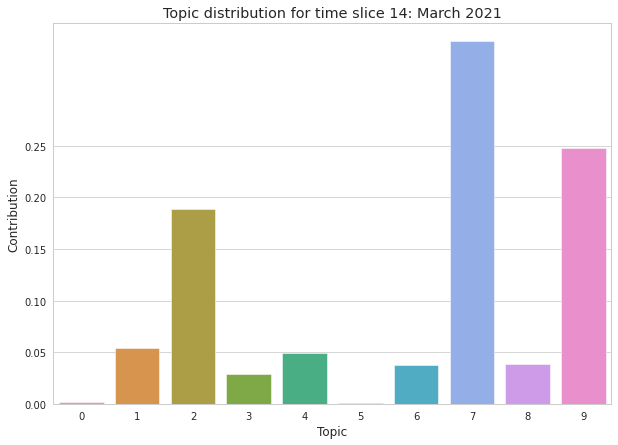

In [35]:
# March 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=14, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics


topics_contribution_sum = topics_contribution_sum/article_per_month[14]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 14: March 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_march_2021 = topics_contribution_sum

Topic 0: implant insulin taste venous tomography elevation pt limb etiology aes edema creatinine oxygenation compensation leg ali disseminated stenosis acute_respiratory_distress_syndrome_ards radiographic

Topic 1: vaccine vaccination dose vaccinated dos prototype trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation esi booster one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se los el grading cutaneous del su ser longterm para que lo eventu

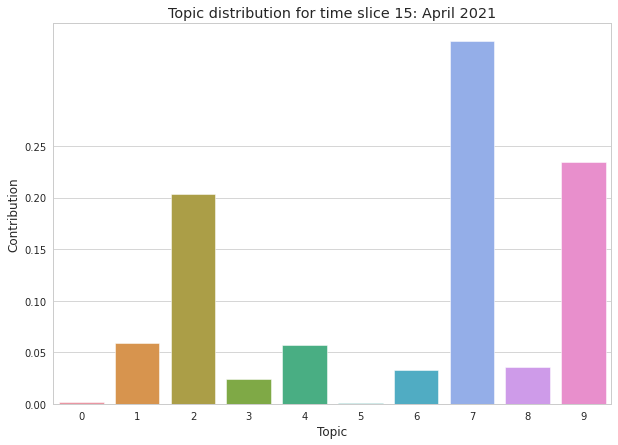

In [36]:
# April 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=15, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[15]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 15: April 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_april_2021 = topics_contribution_sum

Topic 0: insulin implant taste tomography venous elevation pt etiology limb edema creatinine aes leg compensation oxygenation disseminated stenosis ali acdf radiographic

Topic 1: vaccine vaccination dose vaccinated dos prototype trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation esi one-level microdiscectomy booster ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se los el grading cutaneous del su ser para longterm que lo eventual relieve cardiopulmonary sustainin

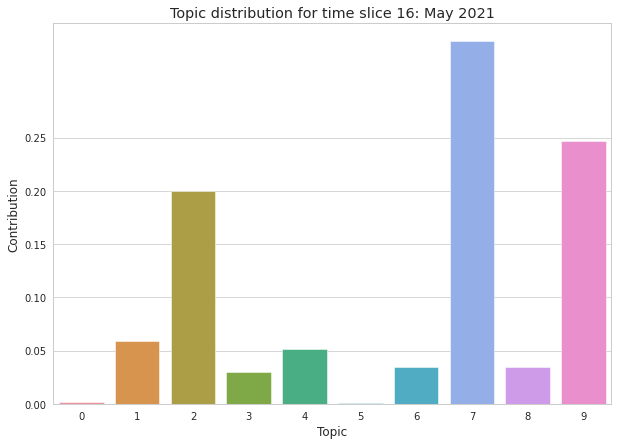

In [37]:
# May 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=16, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[16]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 16: May 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_may_2021 = topics_contribution_sum

Topic 0: insulin taste venous tomography pt elevation implant etiology edema limb creatinine oxygenation compensation disseminated aes leg stenosis acute_respiratory_distress_syndrome_ards radiographic ali

Topic 1: vaccine vaccination dose vaccinated dos prototype trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation esi booster one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se los el grading del cutaneous su ser que para longterm lo eventu

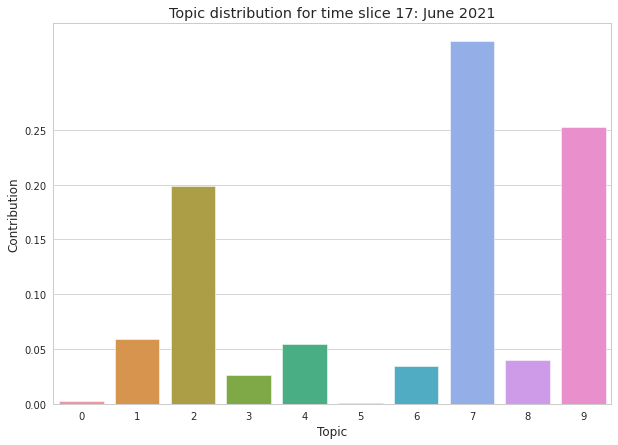

In [38]:
# June 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=17, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[17]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 17: June 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_june_2021 = topics_contribution_sum

Topic 0: insulin venous taste tomography pt elevation edema etiology creatinine limb disseminated implant oxygenation compensation aes leg acute_respiratory_distress_syndrome_ards immunoassay anatomical endoscopic

Topic 1: vaccine vaccination dose vaccinated dos prototype trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation esi booster one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se los el del grading su cutaneous que ser para lo longter

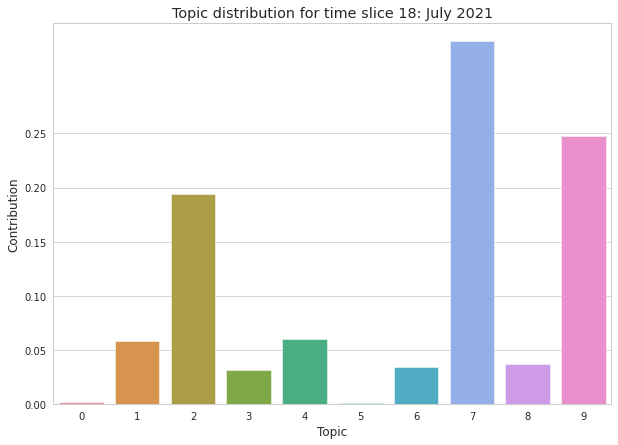

In [39]:
# July 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=18, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[18]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 18: July 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_july_2021 = topics_contribution_sum

Topic 0: insulin venous taste tomography elevation pt edema creatinine etiology disseminated limb oxygenation compensation aes implant acute_respiratory_distress_syndrome_ards leg immunoassay tt anatomical

Topic 1: vaccine vaccination dose vaccinated dos prototype trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se los el del que grading su ser para cutaneous lo por longterm ev

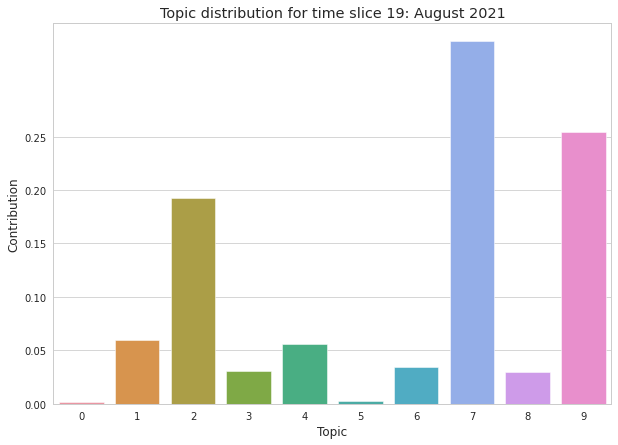

In [40]:
# August 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=19, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[19]

plt.figure(figsize=(10, 7)) 
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 19: August 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_august_2021 = topics_contribution_sum

Topic 0: insulin venous taste elevation tomography pt creatinine edema etiology oxygenation limb disseminated compensation tt immunoassay acute_respiratory_distress_syndrome_ards aes leg anatomical implant

Topic 1: vaccine vaccination dose vaccinated dos prototype trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se los el del que ser su grading para cutaneous lo por longterm ev

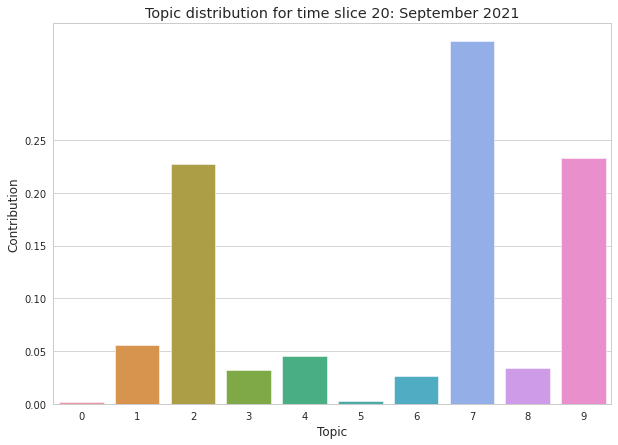

In [41]:
# September 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=20, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[20]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 20: September 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_september_2021 = topics_contribution_sum

Topic 0: insulin venous taste elevation tomography pt creatinine etiology edema limb oxygenation disseminated tt immunoassay compensation acute_respiratory_distress_syndrome_ards calcification anatomical leg endoscopy

Topic 1: vaccine vaccination dose vaccinated dos prototype trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en los el del que su ser grading cutaneous para lo por

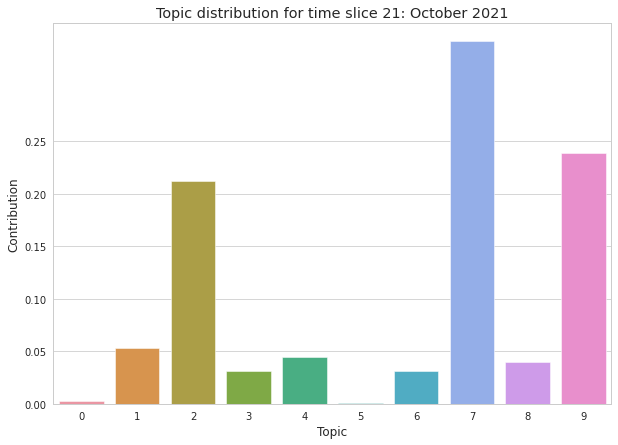

In [42]:
# October 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=21, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[21]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 21: October 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_october_2021 = topics_contribution_sum

Topic 0: insulin venous taste elevation tomography creatinine pt limb etiology edema tt oxygenation calcification disseminated immunoassay endoscopy compensation anatomical acute_respiratory_distress_syndrome_ards leg

Topic 1: vaccine vaccination dose vaccinated prototype dos trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en los el que del su ser grading cutaneous lo para ou 

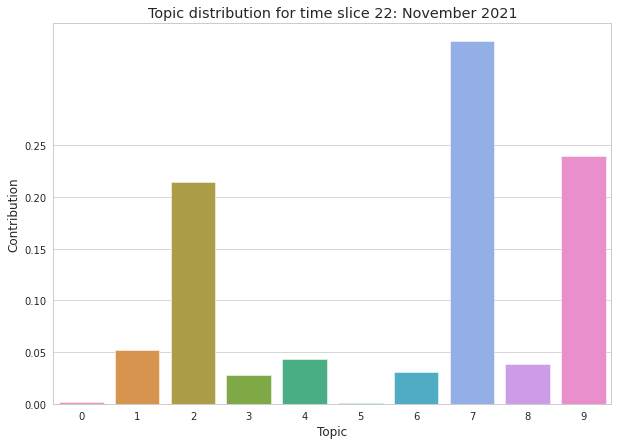

In [43]:
# November 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=22, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[22]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 22: November 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_november_2021 = topics_contribution_sum

Topic 0: insulin venous taste elevation tomography creatinine limb calcification tt etiology edema pt oxygenation endoscopy immunoassay disseminated anatomical compensation acute_respiratory_distress_syndrome_ards leg

Topic 1: vaccine vaccination dose vaccinated prototype dos trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la se en los el que su del lo ser cutaneous grading ou para 

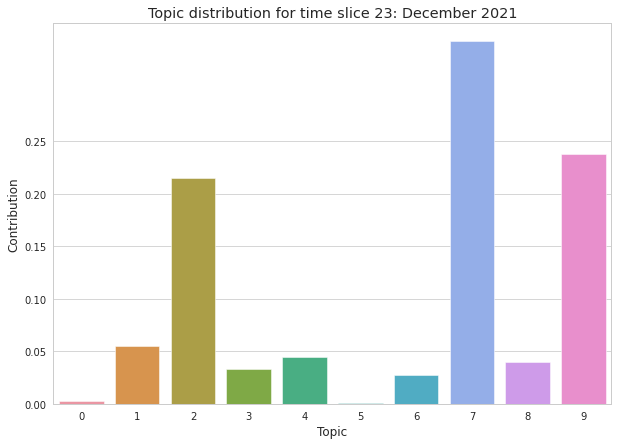

In [44]:
# December 2021
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=23, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[23]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 23: December 2021")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_december_2021 = topics_contribution_sum

Topic 0: insulin venous taste elevation limb creatinine tomography tt endoscopy calcification edema etiology oxygenation pt immunoassay disseminated leg acute_respiratory_distress_syndrome_ards anatomical compensation

Topic 1: vaccine vaccination dose vaccinated prototype dos trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy ligamentum

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se el los que su ou lo del cutaneous grading ser para 

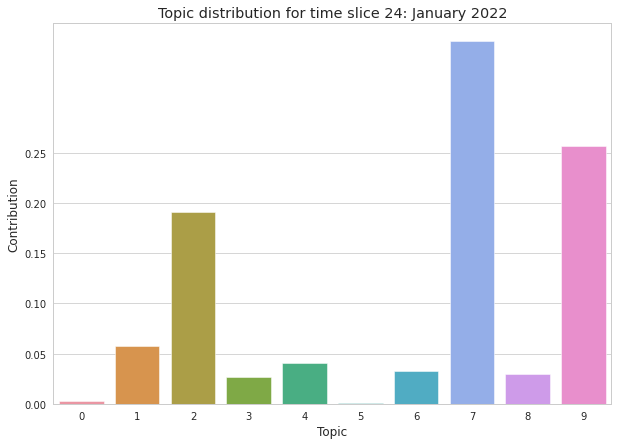

In [45]:
# January 2022
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=24, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[24]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 24: January 2022")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_january_2022 = topics_contribution_sum

Topic 0: insulin venous taste limb elevation endoscopy tt creatinine tomography edema oxygenation etiology pt calcification immunoassay disseminated leg acute_respiratory_distress_syndrome_ards endoscopic implant

Topic 1: vaccine vaccination dose vaccinated prototype dos trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se el los su que ou lo cutaneous del grading para ser hypersens

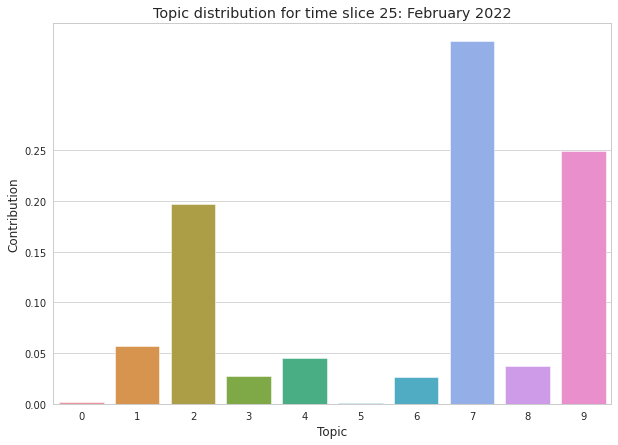

In [46]:
# February 2022
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=25, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24] + article_per_month[25]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[25]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 25: February 2022")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_february_2022 = topics_contribution_sum

Topic 0: insulin venous endoscopy taste limb elevation tt tomography creatinine edema oxygenation etiology pt immunoassay endoscopic disseminated implant leg acute_respiratory_distress_syndrome_ards calcification

Topic 1: vaccine vaccination dose vaccinated prototype dos trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se el su los ou lo que cutaneous del grading para ser por hyper

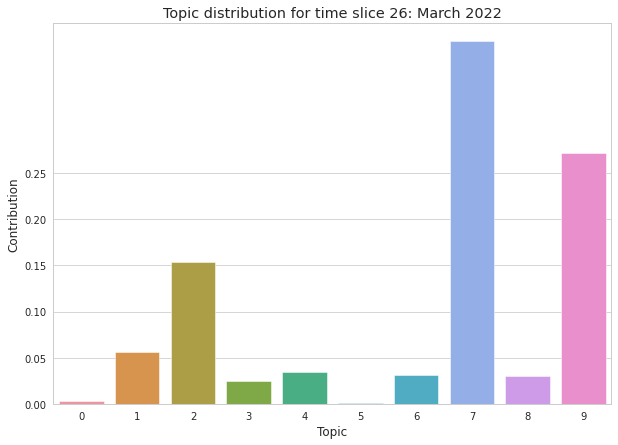

In [47]:
# March 2022
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=26, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24] + article_per_month[25], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24] + article_per_month[25] + article_per_month[26]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[26]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 26: March 2022")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_march_2022 = topics_contribution_sum

Topic 0: insulin endoscopy venous taste limb tt elevation tomography creatinine edema oxygenation etiology pt endoscopic implant immunoassay leg acute_respiratory_distress_syndrome_ards disseminated calcification

Topic 1: vaccine vaccination dose vaccinated prototype dos trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se el su ou lo los que grading del cutaneous para por ser ud hy

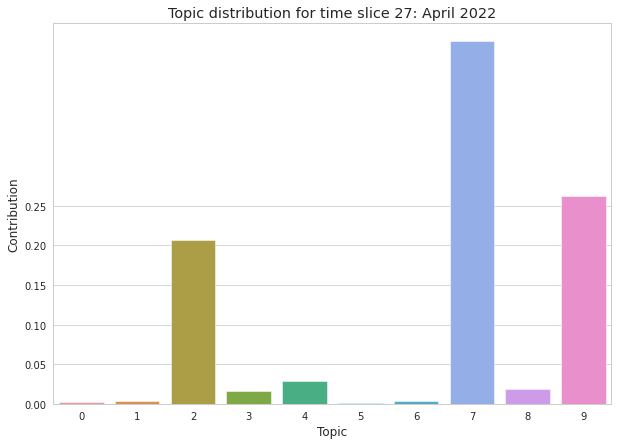

In [48]:
# April 2022
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=27, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))
    
topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24] + article_per_month[25] + article_per_month[26], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24] + article_per_month[25] + article_per_month[26] + article_per_month[27]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[27]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 27: April 2022")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_april_2022 = topics_contribution_sum

Topic 0: insulin endoscopy taste limb venous tt elevation tomography creatinine edema oxygenation endoscopic pt etiology implant immunoassay leg acute_respiratory_distress_syndrome_ards disseminated relapse

Topic 1: vaccine vaccination dose vaccinated prototype dos trial immunization humoral bnt convalescent immunogenicity bcg hesitancy misinformation booster esi one-level microdiscectomy pfizer

Topic 2: research new information technology development process human global country example product economic need user approach model energy market change term

Topic 3: model value method image structure set network feature protein algorithm function interaction parameter performance proposed table binding approach prediction layer

Topic 4: care health medical pandemic hospital participant service need nurse clinical practice staff intervention treatment healthcare support program group research training

Topic 5: la en se el su los ou lo que del para grading cutaneous por ser ud hypersen

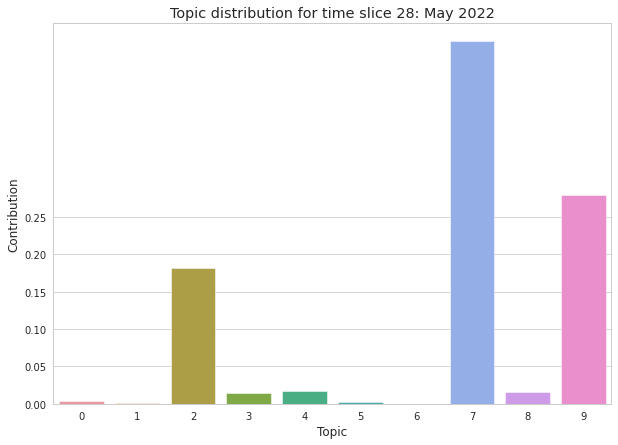

In [49]:
# May 2022
for i in range(0, number_of_topics):
    topics = dtm_model.show_topic(topicid=i, time=28, topn=20)
    # make a array of words
    words = [item[1] for item in topics]
    print("Topic " + str(i) + ": " + ' '.join(words))

topics_contribution_sum = np.zeros(number_of_topics)

for i in range(article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24] + article_per_month[25] + article_per_month[26] + article_per_month[27], article_per_month[0] + article_per_month[1] + article_per_month[2] + article_per_month[3] + article_per_month[4] + article_per_month[5] + article_per_month[6] + article_per_month[7] + article_per_month[8] + article_per_month[9] + article_per_month[10] + article_per_month[11] + article_per_month[12] + article_per_month[13] + article_per_month[14] + article_per_month[15] + article_per_month[16] + article_per_month[17] + article_per_month[18] + article_per_month[19] + article_per_month[20] + article_per_month[21] + article_per_month[22] + article_per_month[23] + article_per_month[24] + article_per_month[25] + article_per_month[26] + article_per_month[27] + article_per_month[28]):
    topics = dtm_model.gamma_[i]
    topics_contribution_sum = topics_contribution_sum + topics

topics_contribution_sum = topics_contribution_sum/article_per_month[28]

plt.figure(figsize=(10, 7))
df_topics = pd.DataFrame(topics_contribution_sum)
df_topics.columns = ['Contribution']
df_topics['Topic'] = range(0, number_of_topics)
sns.set_style("whitegrid", {'axes.grid': True})
sns.barplot(x="Topic", y="Contribution", data=df_topics)
plt.xlabel("Topic")
plt.ylabel("Contribution")
plt.title("Topic distribution for time slice 28: May 2022")
plt.xticks(range(0, number_of_topics))
plt.yticks(np.arange(0, 0.3, 0.05))
plt.show()

topics_may_2022 = topics_contribution_sum

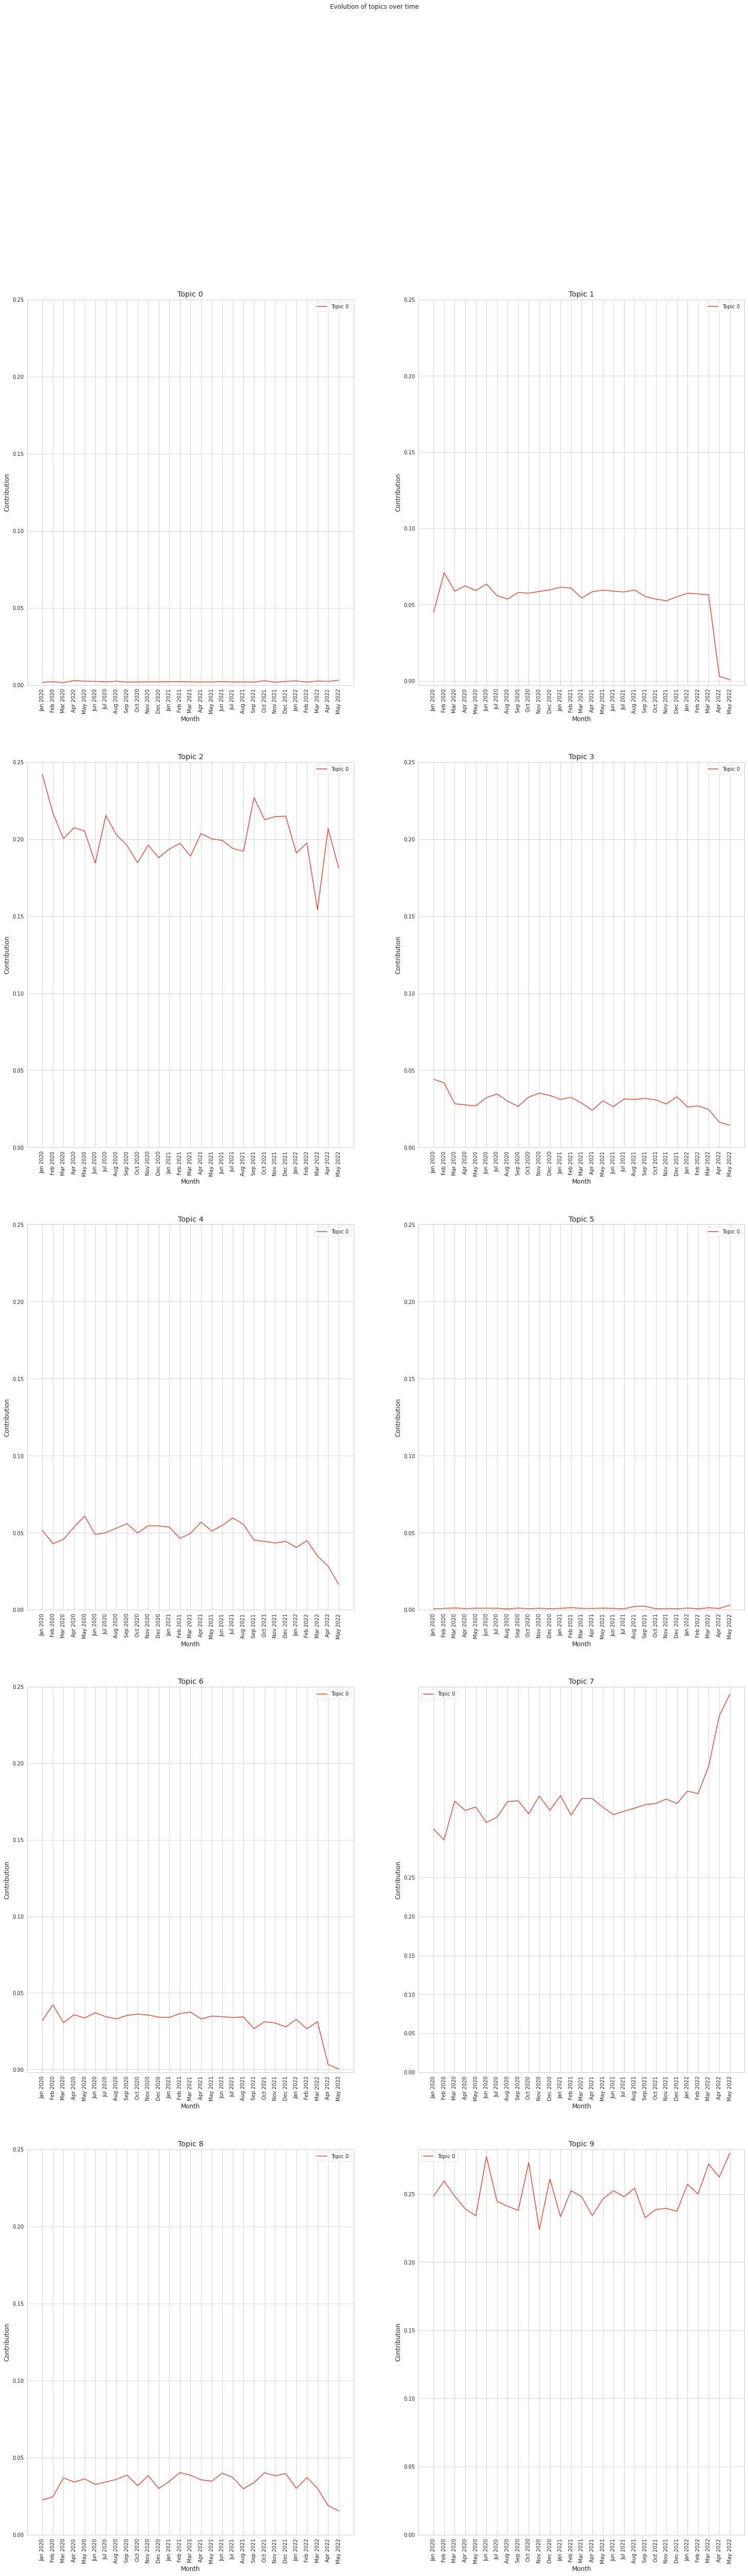

In [50]:
# Study the evolution of topics over time
# concatenate the topics for each month
topic_matrix = [topics_january_2020, topics_february_2020, topics_march_2020, topics_april_2020, topics_may_2020, topics_june_2020, 
                topics_july_2020, topics_august_2020, topics_september_2020, topics_october_2020, topics_november_2020, 
                topics_december_2020, topics_january_2021, topics_february_2021, topics_march_2021, topics_april_2021, 
                topics_may_2021, topics_june_2021, topics_july_2021, topics_august_2021, topics_september_2021, topics_october_2021, 
                topics_november_2021, topics_december_2021, topics_january_2022, topics_february_2022, topics_march_2022, topics_april_2022, 
                topics_may_2022]

months = ['Jan 2020', 'Feb 2020', 'Mar 2020', 'Apr 2020', 'May 2020', 'Jun 2020', 'Jul 2020', 'Aug 2020', 'Sep 2020', 'Oct 2020', 'Nov 2020', 
          'Dec 2020', 'Jan 2021', 'Feb 2021', 'Mar 2021', 'Apr 2021', 'May 2021', 'Jun 2021', 'Jul 2021', 'Aug 2021', 'Sep 2021', 'Oct 2021',
          'Nov 2021', 'Dec 2021', 'Jan 2022', 'Feb 2022', 'Mar 2022', 'Apr 2022', 'May 2022']
                
# plot two graphs side-by-side for all topics (number of graphs = number of topics) two graph per column and number_of_topics/2 rows
fig, axs = plt.subplots(math.ceil(number_of_topics/2), 2, figsize=(25, 80))
fig.suptitle('Evolution of topics over time')
for i in range(0, number_of_topics):
    # all i index values in all rows in topic_matrix is plotted
    topic = [item[i] for item in topic_matrix]
    axs[i//2, i%2].plot(topic)
    axs[i//2, i%2].set_title('Topic ' + str(i))
    axs[i//2, i%2].set_xlabel('Month')
    axs[i//2, i%2].set_ylabel('Contribution')
    axs[ i//2, i%2].set_xticks(range(0, len(months)))
    axs[i//2, i%2].set_xticklabels(months, rotation=90)
    axs[i//2, i%2].set_yticks(np.arange(0, 0.3, 0.05))
    axs[i//2, i%2].legend(['Topic ' + str(i) for i in range(0, number_of_topics)])
    
